In [1]:
import sys
sys.path.insert(0, '..')  # so we can import from src/

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from src.network import make_network, assign_attributes
from src.simulate import run_simulation

%matplotlib inline

In [ ]:
def log_binned_pdf(sizes, n_bins=25):
    """
    Compute a log-binned probability density of avalanche sizes.
    Returns (bin_centers, pdf) for plotting on log-log axes.
    Log binning is essential for visualizing power laws — linear
    binning hides the tail because there's only one event per bin.
    """
    sizes = np.array([s for s in sizes if s > 0])
    if len(sizes) == 0:
        return np.array([]), np.array([])
    
    s_min, s_max = sizes.min(), sizes.max()
    bins = np.logspace(np.log10(s_min), np.log10(s_max + 1), n_bins)
    counts, edges = np.histogram(sizes, bins=bins)
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1] * edges[1:])  # geometric mean
    
    # Normalize by width and total to get a PDF
    total = counts.sum()
    pdf = counts / (widths * total)
    
    # Drop empty bins
    mask = counts > 0
    return centers[mask], pdf[mask]

In [ ]:
G = make_network(N=200, topology='barabasi_albert', mean_degree=4, seed=42)
G = assign_attributes(G, seed=42)

sizes = run_simulation(G, T=50000, sigma=0.02, mu=0.1, burn_in=5000, seed=42)
nonzero = [s for s in sizes if s > 0]
print(f'Total avalanches: {len(nonzero)}')
print(f'Max size: {max(nonzero) if nonzero else 0}')
print(f'Mean size: {np.mean(nonzero):.2f}')

centers, pdf = log_binned_pdf(nonzero)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(centers, pdf, 'o-', markersize=6)
ax.set_xlabel('Avalanche size s')
ax.set_ylabel('P(s)')
ax.set_title(f'σ=0.02, μ=0.1, BA, ⟨k⟩=4, N=200')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Try lowering the threshold to make plants more robust
G = make_network(N=200, topology='barabasi_albert', mean_degree=4, seed=42)
G = assign_attributes(G, threshold=0.2, seed=42)  # MUCH lower threshold

sizes = run_simulation(G, T=50000, sigma=0.05, mu=0.1, burn_in=5000, seed=42)
nonzero = [s for s in sizes if s > 0]
print(f'Total avalanches: {len(nonzero)}')
print(f'Max size: {max(nonzero) if nonzero else 0}')
print(f'Mean size: {np.mean(nonzero):.2f}' if nonzero else 'no events')

centers, pdf = log_binned_pdf(nonzero)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(centers, pdf, 'o-', markersize=6)
ax.set_xlabel('Avalanche size s')
ax.set_ylabel('P(s)')
ax.set_title(f'σ=0.05, μ=0.1, θ=0.2, BA, ⟨k⟩=4, N=200')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Clean rerun with robust threshold — fresh variable names
G_test = make_network(N=200, topology='barabasi_albert', mean_degree=4, seed=42)
G_test = assign_attributes(G_test, threshold=0.2, seed=42)

# Sanity check: confirm threshold actually got set
sample_node = list(G_test.nodes())[0]
print(f"Threshold on sample node: {G_test.nodes[sample_node]['threshold']}")
print(f"(should be 0.2)")

sizes_test = run_simulation(G_test, T=50000, sigma=0.05, mu=0.1, burn_in=5000, seed=42)
nonzero_test = [s for s in sizes_test if s > 0]
print(f'\nTotal avalanches: {len(nonzero_test)}')
print(f'Max size: {max(nonzero_test) if nonzero_test else 0}')
print(f'Mean size: {np.mean(nonzero_test):.2f}' if nonzero_test else 'no events')

centers_test, pdf_test = log_binned_pdf(nonzero_test)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(centers_test, pdf_test, 'o-', markersize=6)
ax.set_xlabel('Avalanche size s')
ax.set_ylabel('P(s)')
ax.set_title('θ=0.2, σ=0.05, μ=0.1, BA, ⟨k⟩=4, N=200')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Diagnostic: prove the simulation is actually running
import importlib
import src.network
import src.simulate
importlib.reload(src.network)
importlib.reload(src.simulate)
from src.network import make_network, assign_attributes
from src.simulate import run_simulation, propagate_cascade
import inspect

# Print the actual source of propagate_cascade so we can confirm the fix is in
print("=== propagate_cascade source ===")
print(inspect.getsource(propagate_cascade))
print("=== end ===\n")

import numpy as np
import time

G = make_network(N=200, topology='barabasi_albert', mean_degree=4, seed=42)
G = assign_attributes(G, threshold=0.2, seed=42)

print(f"Threshold: {G.nodes[0]['threshold']}")

t0 = time.time()
sizes = run_simulation(G, T=5000, sigma=0.05, mu=0.1, burn_in=500, seed=999)
elapsed = time.time() - t0
print(f"Simulation took {elapsed:.2f} seconds")
print(f"Length of sizes: {len(sizes)}")
print(f"First 20 values: {sizes[:20]}")

nonzero = [s for s in sizes if s > 0]
print(f"Nonzero count: {len(nonzero)}")
print(f"Max: {max(nonzero) if nonzero else 0}")

In [ ]:
import importlib
import src.network, src.simulate
importlib.reload(src.network)
importlib.reload(src.simulate)
from src.network import make_network, assign_attributes
from src.simulate import run_simulation

import numpy as np

G = make_network(N=200, topology='barabasi_albert', mean_degree=4, seed=42)
G = assign_attributes(G, threshold=0.1, seed=42)

sizes = run_simulation(G, T=20000, sigma=0.02, mu=0.1, burn_in=2000, seed=999)
nonzero = [s for s in sizes if s > 0]

print(f'Total timesteps: {len(sizes)}')
print(f'Nonzero avalanches: {len(nonzero)}  ({100*len(nonzero)/len(sizes):.1f}%)')
print(f'Max size: {max(nonzero) if nonzero else 0}')
print(f'Mean size: {np.mean(nonzero):.2f}' if nonzero else 'no events')

from collections import Counter
print('\nSize distribution (sorted):')
for size, count in sorted(Counter(nonzero).items())[:20]:
    bar = '#' * min(60, count // max(1, len(nonzero)//200))
    print(f'  size {size:4d}: {count:5d} {bar}')

centers, pdf = log_binned_pdf(nonzero)
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(centers, pdf, 'o-', markersize=6)
ax.set_xlabel('Avalanche size s')
ax.set_ylabel('P(s)')
ax.set_title('θ=0.1, σ=0.02, μ=0.1')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Re-define log_binned_pdf in case it got wiped
def log_binned_pdf(sizes, n_bins=25):
    sizes = np.array([s for s in sizes if s > 0])
    if len(sizes) == 0:
        return np.array([]), np.array([])
    s_min, s_max = sizes.min(), sizes.max()
    bins = np.logspace(np.log10(s_min), np.log10(s_max + 1), n_bins)
    counts, edges = np.histogram(sizes, bins=bins)
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1] * edges[1:])
    total = counts.sum()
    pdf = counts / (widths * total)
    mask = counts > 0
    return centers[mask], pdf[mask]


# Try ER with low connectivity
G = make_network(N=200, topology='erdos_renyi', mean_degree=2, seed=42)
G = assign_attributes(G, threshold=0.1, seed=42)

sizes = run_simulation(G, T=20000, sigma=0.02, mu=0.1, burn_in=2000, seed=999)
nonzero = [s for s in sizes if s > 0]

print(f'Total timesteps: {len(sizes)}')
print(f'Nonzero avalanches: {len(nonzero)}  ({100*len(nonzero)/len(sizes):.1f}%)')
print(f'Max size: {max(nonzero) if nonzero else 0}')
print(f'Mean size: {np.mean(nonzero):.2f}' if nonzero else 'no events')

from collections import Counter
print('\nSize distribution (top 15):')
for size, count in sorted(Counter(nonzero).items())[:15]:
    print(f'  size {size:4d}: {count:5d}')

centers, pdf = log_binned_pdf(nonzero)
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(centers, pdf, 'o-', markersize=6)
ax.set_xlabel('Avalanche size s')
ax.set_ylabel('P(s)')
ax.set_title('ER, ⟨k⟩=2, θ=0.1, σ=0.02, μ=0.1')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import importlib
import src.network, src.simulate
importlib.reload(src.network)
importlib.reload(src.simulate)
from src.network import make_network, assign_attributes
from src.simulate import run_simulation
import numpy as np
from collections import Counter

def log_binned_pdf(sizes, n_bins=25):
    sizes = np.array([s for s in sizes if s > 0])
    if len(sizes) == 0:
        return np.array([]), np.array([])
    s_min, s_max = sizes.min(), sizes.max()
    bins = np.logspace(np.log10(s_min), np.log10(s_max + 1), n_bins)
    counts, edges = np.histogram(sizes, bins=bins)
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1] * edges[1:])
    total = counts.sum()
    pdf = counts / (widths * total)
    mask = counts > 0
    return centers[mask], pdf[mask]


G = make_network(N=200, topology='barabasi_albert', mean_degree=4, seed=42)
G = assign_attributes(G, threshold=0.3, seed=42)

# perturbation_strength = 0.7 means we push the target plant to 30% of nominal
sizes = run_simulation(G, T=30000, sigma=0.7, mu=0.2, burn_in=3000, seed=999)
nonzero = [s for s in sizes if s > 0]

print(f'Total timesteps: {len(sizes)}')
print(f'Nonzero avalanches: {len(nonzero)}  ({100*len(nonzero)/len(sizes):.1f}%)')
print(f'Max size: {max(nonzero) if nonzero else 0}')
print(f'Mean size: {np.mean(nonzero):.2f}' if nonzero else 'no events')

print('\nSize distribution (top 15):')
for size, count in sorted(Counter(nonzero).items())[:15]:
    print(f'  size {size:4d}: {count:5d}')

centers, pdf = log_binned_pdf(nonzero)
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(centers, pdf, 'o-', markersize=6)
ax.set_xlabel('Avalanche size s')
ax.set_ylabel('P(s)')
ax.set_title('BA, ⟨k⟩=4, θ=0.3, single-site drive=0.7, μ=0.2')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import importlib
import src.network, src.simulate
importlib.reload(src.network)
importlib.reload(src.simulate)
from src.network import make_network, assign_attributes
from src.simulate import compute_realized_output, propagate_cascade
import networkx as nx

# Build a tiny known graph: a star, 1 source feeding 5 consumers
G = nx.DiGraph()
G.add_node(0)
for i in range(1, 6):
    G.add_node(i)
    G.add_edge(0, i)

for n in G.nodes():
    G.nodes[n]['Q_nominal'] = 1.0
    G.nodes[n]['threshold'] = 0.3

for u, v in G.edges():
    G.edges[u, v]['weight'] = 1.0 / 5  # equal split

# Healthy state, then drop node 0 to 30% capacity
state = {
    'tripped': set(),
    'effective_capacity': {0: 0.3, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0}
}

print("Before cascade:")
realized = compute_realized_output(G, state)
print(f"  realized: {realized}")
print(f"  fractions (realized/eff_cap): {[(n, realized[n]/state['effective_capacity'][n]) for n in G.nodes()]}")

avalanche = propagate_cascade(G, state)
print(f"\nAvalanche size: {len(avalanche)}")
print(f"Tripped: {sorted(avalanche)}")
print(f"Final state.tripped: {sorted(state['tripped'])}")

In [ ]:
import importlib
import src.network, src.simulate
importlib.reload(src.network)
importlib.reload(src.simulate)
from src.network import make_network, assign_attributes
from src.simulate import run_simulation
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def log_binned_pdf(sizes, n_bins=25):
    sizes = np.array([s for s in sizes if s > 0])
    if len(sizes) == 0:
        return np.array([]), np.array([])
    s_min, s_max = sizes.min(), sizes.max()
    bins = np.logspace(np.log10(s_min), np.log10(s_max + 1), n_bins)
    counts, edges = np.histogram(sizes, bins=bins)
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1] * edges[1:])
    total = counts.sum()
    pdf = counts / (widths * total)
    mask = counts > 0
    return centers[mask], pdf[mask]


# Scan: vary perturbation strength AND threshold together
# We want a regime where size 1 dominates and the tail is heavy

configs = [
    # (threshold, perturbation_strength, label)
    (0.5, 0.4, "θ=0.5, p=0.4"),
    (0.5, 0.5, "θ=0.5, p=0.5"),
    (0.5, 0.6, "θ=0.5, p=0.6"),
    (0.7, 0.4, "θ=0.7, p=0.4"),
    (0.7, 0.5, "θ=0.7, p=0.5"),
    (0.7, 0.6, "θ=0.7, p=0.6"),
    (0.9, 0.3, "θ=0.9, p=0.3"),
    (0.9, 0.4, "θ=0.9, p=0.4"),
    (0.9, 0.5, "θ=0.9, p=0.5"),
]

fig, axes = plt.subplots(3, 3, figsize=(13, 11), sharex=True, sharey=True)

for ax, (theta, pstr, label) in zip(axes.flat, configs):
    G = make_network(N=200, topology='erdos_renyi', mean_degree=3, seed=42)
    G = assign_attributes(G, threshold=theta, seed=42)
    sizes = run_simulation(G, T=15000, sigma=pstr, mu=0.2, burn_in=1500, seed=999)
    nonzero = [s for s in sizes if s > 0]
    
    if len(nonzero) < 20:
        ax.set_title(f'{label}\n(only {len(nonzero)} events)', fontsize=9)
        continue
    
    # Count size-1 events to check if we're in SOC window
    n1 = sum(1 for s in nonzero if s == 1)
    n_total = len(nonzero)
    
    centers, pdf = log_binned_pdf(nonzero)
    ax.loglog(centers, pdf, 'o-', markersize=4)
    ax.set_title(f'{label}\nN_av={n_total}, max={max(nonzero)}, size1={n1}', fontsize=9)
    ax.grid(True, which='both', alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('size s')
for ax in axes[:, 0]:
    ax.set_ylabel('P(s)')

plt.suptitle('ER ⟨k⟩=3, scanning threshold × perturbation strength', y=1.0)
plt.tight_layout()
plt.show()

In [ ]:
import importlib
import src.simulate
importlib.reload(src.simulate)
import inspect

print("=" * 60)
print("apply_localized_perturbation source:")
print("=" * 60)
print(inspect.getsource(src.simulate.apply_localized_perturbation))

print("=" * 60)
print("run_simulation source:")
print("=" * 60)
print(inspect.getsource(src.simulate.run_simulation))

print("=" * 60)
print("propagate_cascade source:")
print("=" * 60)
print(inspect.getsource(src.simulate.propagate_cascade))

print("=" * 60)
print("compute_realized_output source:")
print("=" * 60)
print(inspect.getsource(src.simulate.compute_realized_output))

In [ ]:
import importlib
import src.network, src.simulate
importlib.reload(src.network)
importlib.reload(src.simulate)
from src.network import make_network, assign_attributes
from src.simulate import compute_realized_output, propagate_cascade, run_simulation
import networkx as nx
import numpy as np
from collections import Counter

# Test 1: toy star (should still work)
G = nx.DiGraph()
G.add_node(0)
for i in range(1, 6):
    G.add_node(i)
    G.add_edge(0, i)
for n in G.nodes():
    G.nodes[n]['Q_nominal'] = 1.0
    G.nodes[n]['threshold'] = 0.3
for u, v in G.edges():
    G.edges[u, v]['weight'] = 1.0 / 5

state = {'tripped': set(), 'effective_capacity': {0: 0.3, 1:1.0, 2:1.0, 3:1.0, 4:1.0, 5:1.0}}
print("Toy star, source at 0.3:")
print(f"  realized: {compute_realized_output(G, state)}")
print(f"  avalanche: {propagate_cascade(G, state)}")

# Test 2: small cycle (the previous bug)
G2 = nx.DiGraph()
G2.add_edges_from([(0,1),(1,2),(2,0)])  # 3-cycle
for n in G2.nodes():
    G2.nodes[n]['Q_nominal'] = 1.0
    G2.nodes[n]['threshold'] = 0.3
for u, v in G2.edges():
    G2.edges[u, v]['weight'] = 1.0

state2 = {'tripped': set(), 'effective_capacity': {0: 1.0, 1: 1.0, 2: 1.0}}
print("\n3-cycle, all healthy:")
print(f"  realized: {compute_realized_output(G2, state2)}")
print(f"  (should be all 1.0)")

# Test 3: full simulation
G3 = make_network(N=200, topology='erdos_renyi', mean_degree=3, seed=42)
G3 = assign_attributes(G3, threshold=0.5, seed=42)
sizes = run_simulation(G3, T=20000, sigma=0.7, mu=0.2, burn_in=2000, seed=999)
nonzero = [s for s in sizes if s > 0]

print(f'\nFull simulation:')
print(f'  Nonzero avalanches: {len(nonzero)} ({100*len(nonzero)/len(sizes):.1f}%)')
print(f'  Max size: {max(nonzero) if nonzero else 0}')
print(f'  Mean size: {np.mean(nonzero):.2f}' if nonzero else '  no events')
print(f'  Top sizes:')
for size, count in sorted(Counter(nonzero).items())[:10]:
    print(f'    size {size}: {count}')

In [ ]:
import importlib
import src.network, src.simulate
importlib.reload(src.network)
importlib.reload(src.simulate)
from src.network import make_network, assign_attributes
from src.simulate import run_simulation
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

def log_binned_pdf(sizes, n_bins=25):
    sizes = np.array([s for s in sizes if s > 0])
    if len(sizes) == 0:
        return np.array([]), np.array([])
    s_min, s_max = sizes.min(), sizes.max()
    bins = np.logspace(np.log10(s_min), np.log10(s_max + 1), n_bins)
    counts, edges = np.histogram(sizes, bins=bins)
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1] * edges[1:])
    total = counts.sum()
    pdf = counts / (widths * total)
    mask = counts > 0
    return centers[mask], pdf[mask]


G = make_network(N=300, topology='barabasi_albert', mean_degree=4, seed=42)
G = assign_attributes(G, seed=42)

sizes = run_simulation(G, T=20000, sigma=0.0, mu=0.0, burn_in=2000, seed=999)
nonzero = [s for s in sizes if s > 0]

print(f'Total: {len(sizes)}, nonzero: {len(nonzero)}')
print(f'Max: {max(nonzero) if nonzero else 0}, mean: {np.mean(nonzero):.2f}')
print('\nTop 12 sizes:')
for size, count in sorted(Counter(nonzero).items())[:12]:
    print(f'  size {size}: {count}')

centers, pdf = log_binned_pdf(nonzero)
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(centers, pdf, 'o-', markersize=6)
ax.set_xlabel('Avalanche size s')
ax.set_ylabel('P(s)')
ax.set_title('Motter-Lai cascade, BA, ⟨k⟩=4, N=300, α=0.3')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

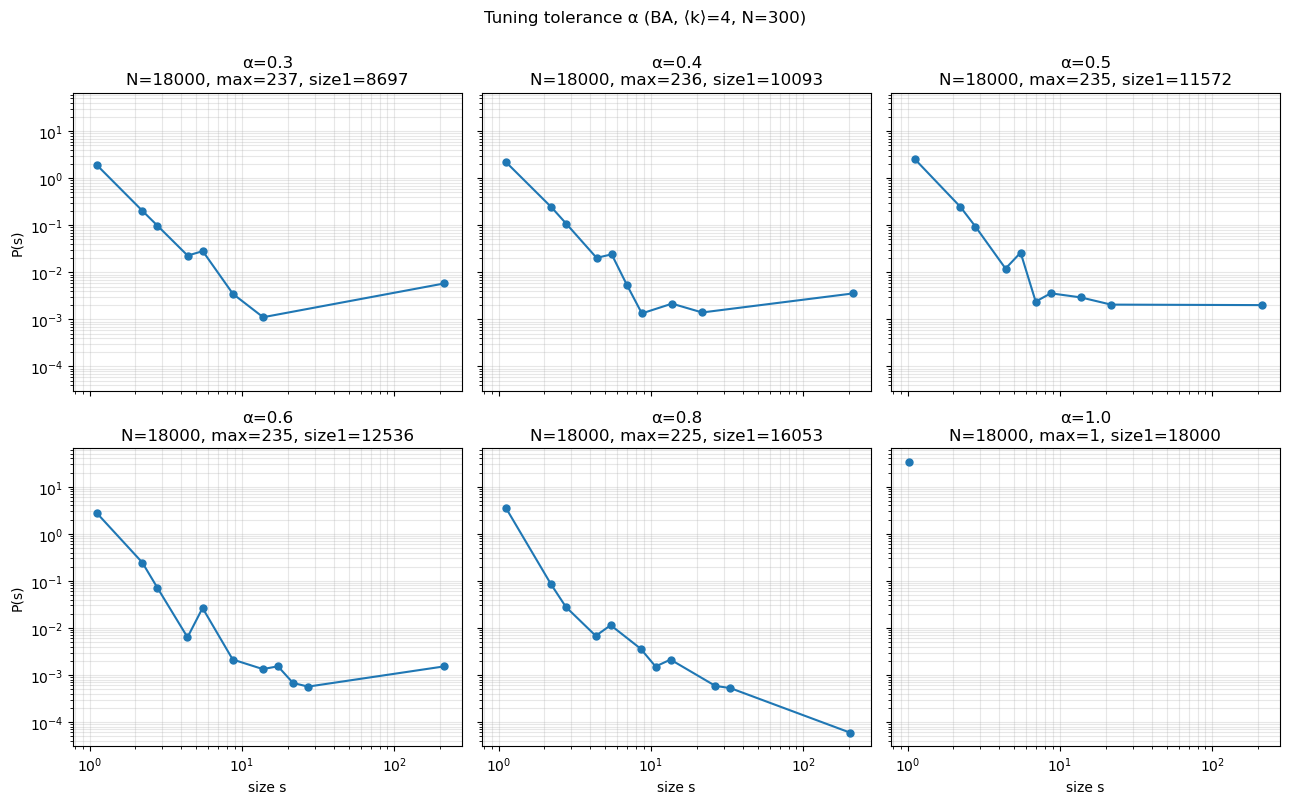

In [2]:
import importlib
import src.network, src.simulate
importlib.reload(src.network)
importlib.reload(src.simulate)
from src.network import make_network, assign_attributes
from src.simulate import run_simulation
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

def log_binned_pdf(sizes, n_bins=25):
    sizes = np.array([s for s in sizes if s > 0])
    if len(sizes) == 0:
        return np.array([]), np.array([])
    s_min, s_max = sizes.min(), sizes.max()
    bins = np.logspace(np.log10(s_min), np.log10(s_max + 1), n_bins)
    counts, edges = np.histogram(sizes, bins=bins)
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1] * edges[1:])
    total = counts.sum()
    pdf = counts / (widths * total)
    mask = counts > 0
    return centers[mask], pdf[mask]

alphas = [0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True)

for ax, alpha in zip(axes.flat, alphas):
    G = make_network(N=300, topology='barabasi_albert', mean_degree=4, seed=42)
    G = assign_attributes(G, seed=42)
    sizes = run_simulation(G, T=20000, sigma=0.0, mu=0.0, burn_in=2000, seed=999, alpha=alpha)
    nonzero = [s for s in sizes if s > 0]
    
    if len(nonzero) < 20:
        ax.set_title(f'α={alpha}\n(few events)')
        continue
    
    n1 = sum(1 for s in nonzero if s == 1)
    centers, pdf = log_binned_pdf(nonzero)
    ax.loglog(centers, pdf, 'o-', markersize=5)
    ax.set_title(f'α={alpha}\nN={len(nonzero)}, max={max(nonzero)}, size1={n1}')
    ax.grid(True, which='both', alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('size s')
for ax in axes[:, 0]:
    ax.set_ylabel('P(s)')

plt.suptitle('Tuning tolerance α (BA, ⟨k⟩=4, N=300)', y=1.0)
plt.tight_layout()
plt.show()

Total avalanches: 90000
Max size: 225
Mean size: 2.28

Power-law fit:
  alpha (tau) = 1.963
  x_min       = 2.0
  sigma_alpha = 0.010

Power law vs exponential:  R=8578.023, p=0.0000
Power law vs lognormal:    R=-10.471, p=0.0000


/Users/jaagravshakalya/Desktop/circular-economy-soc/venv/lib/python3.12/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution lognormal.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


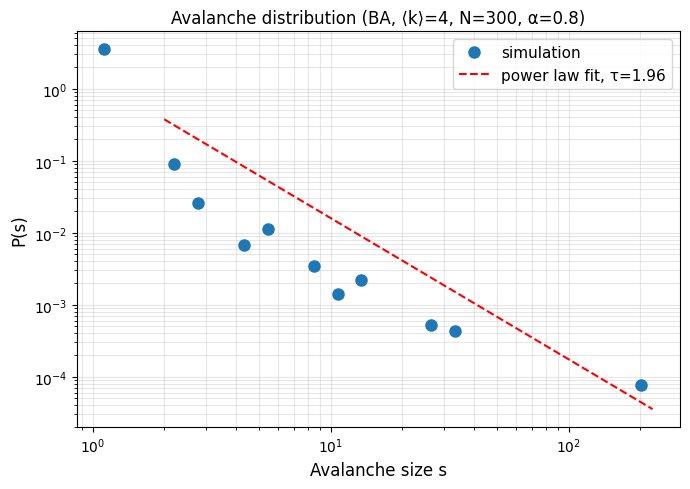


Saved figures/phase3_powerlaw_fit.png


In [2]:
import importlib
import src.network, src.simulate
importlib.reload(src.network)
importlib.reload(src.simulate)
from src.network import make_network, assign_attributes
from src.simulate import run_simulation
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

def log_binned_pdf(sizes, n_bins=25):
    sizes = np.array([s for s in sizes if s > 0])
    if len(sizes) == 0:
        return np.array([]), np.array([])
    s_min, s_max = sizes.min(), sizes.max()
    bins = np.logspace(np.log10(s_min), np.log10(s_max + 1), n_bins)
    counts, edges = np.histogram(sizes, bins=bins)
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1] * edges[1:])
    total = counts.sum()
    pdf = counts / (widths * total)
    mask = counts > 0
    return centers[mask], pdf[mask]


# LOCKED-IN PARAMETERS
ALPHA = 0.8
N = 300
T = 100000
BURN_IN = 10000

G = make_network(N=N, topology='barabasi_albert', mean_degree=4, seed=42)
G = assign_attributes(G, seed=42)
sizes = run_simulation(G, T=T, sigma=0.0, mu=0.0, burn_in=BURN_IN, seed=999, alpha=ALPHA)
nonzero = np.array([s for s in sizes if s > 0])

print(f'Total avalanches: {len(nonzero)}')
print(f'Max size: {nonzero.max()}')
print(f'Mean size: {nonzero.mean():.2f}')

# Power-law fit
fit = powerlaw.Fit(nonzero, discrete=True, verbose=False)
print(f'\nPower-law fit:')
print(f'  alpha (tau) = {fit.power_law.alpha:.3f}')
print(f'  x_min       = {fit.power_law.xmin}')
print(f'  sigma_alpha = {fit.power_law.sigma:.3f}')

R, p = fit.distribution_compare('power_law', 'exponential')
print(f'\nPower law vs exponential:  R={R:.3f}, p={p:.4f}')
R2, p2 = fit.distribution_compare('power_law', 'lognormal')
print(f'Power law vs lognormal:    R={R2:.3f}, p={p2:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
centers, pdf = log_binned_pdf(nonzero)
ax.loglog(centers, pdf, 'o', markersize=8, label='simulation')
fit.power_law.plot_pdf(ax=ax, color='r', linestyle='--',
                       label=f'power law fit, τ={fit.power_law.alpha:.2f}')
ax.set_xlabel('Avalanche size s', fontsize=12)
ax.set_ylabel('P(s)', fontsize=12)
ax.set_title(f'Avalanche distribution (BA, ⟨k⟩=4, N=300, α={ALPHA})')
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/phase3_powerlaw_fit.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved figures/phase3_powerlaw_fit.png')